<a href="https://colab.research.google.com/github/FlyAIBox/langchain-academy/blob/fly101/module-3/edit-state-human-feedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 图状态编辑与人工反馈

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/edit-state-human-feedback.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239520-lesson-3-editing-state-and-human-feedback)

## 本教程简介

本教程将向您展示如何在LangGraph中编辑图状态并集成人工反馈。这是构建人机协作AI系统的关键技术，让人类可以在AI执行过程中进行干预和指导。

# 编辑图状态

## 回顾

我们之前讨论了人机协作（human-in-the-loop）的动机：

**(1) 审批（Approval）** - 我们可以中断智能体，向用户展示状态，并允许用户接受某个操作

**(2) 调试（Debugging）** - 我们可以回滚图来重现或避免问题

**(3) 编辑（Editing）** - 您可以修改状态

我们展示了断点如何支持用户审批，但还不知道如何在图被中断后修改图状态！

## 学习目标

现在，让我们展示如何直接编辑图状态并插入人工反馈。

In [1]:
# 安装必要的依赖包
# 这些包是构建LangGraph应用的核心组件
%%capture --no-stderr
# %pip install --quiet -U langgraph langchain_openai langgraph_sdk langgraph-prebuilt
%pip install --quiet langgraph==0.6.7 langchain_openai==0.3.32 langgraph_sdk==0.2.6 langgraph-prebuilt==0.6.4

In [2]:
# 设置环境变量
import os, getpass

def _set_env(var: str):
    """安全地设置环境变量，如果不存在则提示用户输入"""
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# 设置OpenAI API密钥，这是使用OpenAI模型所必需的
_set_env("OPENAI_API_KEY")
# 设置 OpenAI API代理地址 (例如：https://api.apiyi.com/v1）
_set_env("OPENAI_BASE_URL")

OPENAI_API_KEY: ··········
OPENAI_BASE_URL: ··········


## 编辑状态

之前，我们介绍了断点（breakpoints）。

我们使用断点来中断图，并在执行下一个节点之前等待用户审批。

但断点也是[修改图状态的机会](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/edit-graph-state/)。

让我们在`assistant`节点之前设置一个断点来构建我们的智能体。

In [4]:
# 导入必要的库
from langchain_openai import ChatOpenAI

# 定义数学运算工具函数
def multiply(a: int, b: int) -> int:
    """乘法运算：计算两个整数的乘积

    Args:
        a: 第一个整数
        b: 第二个整数
    """
    return a * b

def add(a: int, b: int) -> int:
    """加法运算：计算两个整数的和

    Args:
        a: 第一个整数
        b: 第二个整数
    """
    return a + b

def divide(a: int, b: int) -> float:
    """除法运算：计算两个整数的商

    Args:
        a: 被除数
        b: 除数
    """
    return a / b

# 将工具函数组合成工具列表
tools = [add, multiply, divide]

# 初始化OpenAI聊天模型
llm = ChatOpenAI(model="gpt-4o")

# 将工具绑定到语言模型，使模型能够调用这些工具
llm_with_tools = llm.bind_tools(tools)

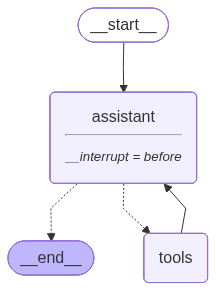

In [5]:
# 导入必要的库
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

# 定义系统消息，指导AI助手的行为
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# 定义助手节点函数
def assistant(state: MessagesState):
    """助手节点：使用语言模型处理消息并可能调用工具

    Args:
        state: 包含消息列表的图状态

    Returns:
        包含AI响应的新状态更新
    """
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# 创建状态图构建器
builder = StateGraph(MessagesState)

# 定义节点：这些节点执行具体的工作
builder.add_node("assistant", assistant)  # AI助手节点
builder.add_node("tools", ToolNode(tools))  # 工具执行节点

# 定义边：这些边决定控制流程
builder.add_edge(START, "assistant")  # 从开始到助手
builder.add_conditional_edges(
    "assistant",
    # 如果助手的最新消息是工具调用 -> tools_condition 路由到工具节点
    # 如果助手的最新消息不是工具调用 -> tools_condition 路由到结束
    tools_condition,
)
builder.add_edge("tools", "assistant")  # 从工具回到助手

# 创建内存检查点保存器，用于保存图状态
memory = MemorySaver()

# 编译图，在assistant节点之前设置中断点
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# 显示图的可视化结构
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

让我们运行图！

我们可以看到图在聊天模型响应之前被中断了。

In [6]:
# 定义初始输入：用户要求进行数学运算
initial_input = {"messages": "Multiply 2 and 3"}

# 创建线程配置，用于跟踪对话状态
thread = {"configurable": {"thread_id": "1"}}

# 运行图直到第一个中断点
# 由于设置了interrupt_before=["assistant"]，图会在assistant节点执行前停止
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [7]:
# 获取当前图状态，查看中断时的状态信息
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='47164047-b316-461d-a6db-b688fe22b9e2')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08fb04-cc7f-6ab3-8000-bd10cf2ba52e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-09-12T08:13:01.367558+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f08fb04-cc7d-67ae-bfff-212de85ada55'}}, tasks=(PregelTask(id='4751155e-2a98-83df-df8a-f489f43e45d3', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

现在，我们可以直接应用状态更新。

记住，对`messages`键的更新将使用`add_messages`归约器：

* 如果我们想要覆盖现有消息，可以提供消息的`id`。
* 如果我们只是想要追加到消息列表中，那么可以传递一个没有指定`id`的消息，如下所示。

In [8]:
# 更新图状态：添加新的人类消息
# 这里我们添加一条新消息来修改用户的原始请求
graph.update_state(
    thread,
    {"messages": [HumanMessage(content="No, actually multiply 3 and 3!")]},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f08fb05-0434-60e6-8001-c9837f4ce146'}}

让我们看一下结果。

我们使用新消息调用了`update_state`。

`add_messages`归约器将其追加到我们的状态键`messages`中。

In [9]:
# 获取更新后的状态并显示所有消息
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, actually multiply 3 and 3!


现在，让我们继续执行我们的智能体，只需传递`None`并允许它从当前状态继续。

我们发出当前状态，然后继续执行剩余的节点。

In [10]:
# 继续执行图，从当前中断点开始
# 传递None表示从当前状态继续，而不是重新开始
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 3 and 3!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_uAdcIWOIU6ToL8jpdhIwy9NE)
 Call ID: call_uAdcIWOIU6ToL8jpdhIwy9NE
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: multiply

9


现在，我们又回到了`assistant`节点，它设置了我们的`breakpoint`。

我们可以再次传递`None`来继续执行。

In [11]:
# 继续执行图，完成剩余的计算
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

9
================================== Ai Message ==================================

The product of 3 and 3 is 9.


### 在Studio中编辑图状态

**⚠️ 免责声明**

自这些视频拍摄以来，我们已经更新了Studio，使其可以在本地运行并在浏览器中打开。这是现在运行Studio的首选方式（而不是使用视频中显示的桌面应用程序）。请参阅[本地开发服务器](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/#local-development-server)的文档和[运行开发服务器](https://langchain-ai.github.io/langgraph/how-tos/local-studio/#run-the-development-server)的文档。要启动本地开发服务器，请在此模块的`/studio`目录中的终端运行以下命令：

```
langgraph dev
```

您应该看到以下输出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打开您的浏览器并导航到Studio UI：`https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`。

LangGraph API [支持编辑图状态](https://langchain-ai.github.io/langgraph/cloud/how-tos/human_in_the_loop_edit_state/#initial-invocation)。

In [ ]:
# 检查是否在Google Colab环境中运行
# LangGraph Studio目前不支持在Google Colab中运行
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [ ]:
# 这是本地开发服务器的URL
# 创建LangGraph SDK客户端，用于与本地Studio服务器通信
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

我们的智能体定义在`studio/agent.py`中。

如果您查看代码，您会发现它*没有*断点！

当然，我们可以将其添加到`agent.py`中，但API的一个非常好的功能是我们可以传入断点！

在这里，我们传递`interrupt_before=["assistant"]`。

In [ ]:
# 使用LangGraph SDK创建线程并运行智能体
initial_input = {"messages": "Multiply 2 and 3"}
thread = await client.threads.create()

# 异步流式运行智能体，在assistant节点前中断
async for chunk in client.runs.stream(
    thread["thread_id"],
    "agent",
    input=initial_input,
    stream_mode="values",
    interrupt_before=["assistant"],  # 在assistant节点前设置中断点
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46', 'example': False}
--------------------------------------------------


我们可以获取当前状态

In [ ]:
# 获取当前线程的状态信息
current_state = await client.threads.get_state(thread['thread_id'])
current_state

{'values': {'messages': [{'content': 'Multiply 2 and 3',
    'additional_kwargs': {},
    'response_metadata': {},
    'type': 'human',
    'name': None,
    'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
    'example': False}]},
 'next': ['assistant'],
 'tasks': [{'id': 'a71c0b80-a679-57cb-aa59-a1655b763480',
   'name': 'assistant',
   'error': None,
   'interrupts': [],
   'state': None}],
 'metadata': {'step': 0,
  'run_id': '1ef6a41c-ea63-663f-b3e8-4f001bf0bf53',
  'source': 'loop',
  'writes': None,
  'parents': {},
  'user_id': '',
  'graph_id': 'agent',
  'thread_id': 'a95ffa54-2435-4a47-a9da-e886369ca8ee',
  'created_by': 'system',
  'assistant_id': 'fe096781-5601-53d2-b2f6-0d3403f7e9ca'},
 'created_at': '2024-09-03T22:13:54.466695+00:00',
 'checkpoint_id': '1ef6a41c-ead7-637b-8000-8c6a7b98379e',
 'parent_checkpoint_id': '1ef6a41c-ead3-637d-bfff-397ebdb4f2ea'}

我们可以查看状态中的最后一条消息。

In [ ]:
# 获取状态中的最后一条消息
last_message = current_state['values']['messages'][-1]
last_message

{'content': 'Multiply 2 and 3',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
 'example': False}

我们可以编辑它！

In [ ]:
# 修改最后一条消息的内容
last_message['content'] = "No, actually multiply 3 and 3!"
last_message

{'content': 'No, actually multiply 3 and 3!',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
 'example': False}

In [ ]:
# 显示修改后的消息
last_message

{'content': 'No, actually multiply 3 and 3!',
 'additional_kwargs': {},
 'response_metadata': {},
 'type': 'human',
 'name': None,
 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46',
 'example': False}

记住，正如我们之前所说，对`messages`键的更新将使用相同的`add_messages`归约器。

如果我们想要覆盖现有消息，那么我们可以提供消息的`id`。

在这里，我们就是这样做的。我们只修改了消息的`content`，如上所示。

In [ ]:
# 使用修改后的消息更新线程状态
await client.threads.update_state(thread['thread_id'], {"messages": last_message})

{'configurable': {'thread_id': 'a95ffa54-2435-4a47-a9da-e886369ca8ee',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a41d-cc8e-6979-8001-8c7c283b636c'},
 'checkpoint_id': '1ef6a41d-cc8e-6979-8001-8c7c283b636c'}

现在，我们通过传递`None`来恢复执行。

In [ ]:
# 恢复执行：从当前中断点继续运行智能体
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,  # 传递None表示从当前状态继续
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'No, actually multiply 3 and 3!', 'additional_kwargs': {'additional_kwargs': {}, 'response_metadata': {}, 'example': False}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '882dabe4-b877-4d71-bd09-c34cb97c4f46', 'example': False}
--------------------------------------------------
Receiving new event of type: values...
{'content': '', 'additional_kwargs': {'tool_calls': [{'index': 0, 'id': 'call_vi16je2EIikHuT7Aue2sd1qd', 'function': {'arguments': '{"a":3,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, 'response_metadata': {'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-775b42f7-0590-4c54-aaeb-78599b1f12d2', 'example': False, 'tool_calls': [{'name': 'multiply', 'args': {'a': 3, 'b': 3}, 'id': 'call_vi16je2EIikHuT7Aue2sd1qd', 'type

我们得到了工具调用的结果`9`，正如预期的那样。

In [ ]:
# 继续执行，完成最终响应
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=None,
    stream_mode="values",
    interrupt_before=["assistant"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': '9', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'multiply', 'id': '226bfbad-0cea-4900-80c5-761a62bd4bc1', 'tool_call_id': 'call_vi16je2EIikHuT7Aue2sd1qd', 'artifact': None, 'status': 'success'}
--------------------------------------------------
Receiving new event of type: values...
{'content': 'The result of multiplying 3 by 3 is 9.', 'additional_kwargs': {}, 'response_metadata': {'finish_reason': 'stop', 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_157b3831f5'}, 'type': 'ai', 'name': None, 'id': 'run-859bbf47-9f35-4e71-ae98-9d93ee49d16c', 'example': False, 'tool_calls': [], 'invalid_tool_calls': [], 'usage_metadata': None}
--------------------------------------------------


## 等待用户输入

所以，很明显我们可以在断点后编辑智能体状态。

现在，如果我们想要允许人工反馈来执行这种状态更新呢？

我们将在智能体中添加一个[作为人工反馈占位符的节点](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/#setup)。

这个`human_feedback`节点允许用户直接向状态添加反馈。

我们使用`interrupt_before`在我们的`human_feedback`节点前指定断点。

我们设置一个检查点保存器来保存图的状态直到这个节点。

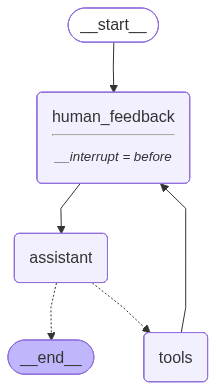

In [12]:
# 定义系统消息
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# 人工反馈节点：这是一个空操作节点，应该在此处中断
def human_feedback(state: MessagesState):
    """人工反馈节点：用于接收和处理用户输入

    Args:
        state: 包含消息列表的图状态

    Returns:
        无返回值，此节点主要用于中断点
    """
    pass

# 助手节点
def assistant(state: MessagesState):
    """助手节点：使用语言模型处理消息并可能调用工具

    Args:
        state: 包含消息列表的图状态

    Returns:
        包含AI响应的新状态更新
    """
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# 创建状态图构建器
builder = StateGraph(MessagesState)

# 定义节点：这些节点执行具体的工作
builder.add_node("assistant", assistant)  # AI助手节点
builder.add_node("tools", ToolNode(tools))  # 工具执行节点
builder.add_node("human_feedback", human_feedback)  # 人工反馈节点

# 定义边：这些边决定控制流程
builder.add_edge(START, "human_feedback")  # 从开始到人工反馈
builder.add_edge("human_feedback", "assistant")  # 从人工反馈到助手
builder.add_conditional_edges(
    "assistant",
    # 如果助手的最新消息是工具调用 -> tools_condition 路由到工具节点
    # 如果助手的最新消息不是工具调用 -> tools_condition 路由到结束
    tools_condition,
)
builder.add_edge("tools", "human_feedback")  # 从工具回到人工反馈

# 创建内存检查点保存器
memory = MemorySaver()

# 编译图，在human_feedback节点前设置中断点
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

# 显示图的可视化结构
display(Image(graph.get_graph().draw_mermaid_png()))

我们将从用户那里获得反馈。

我们使用`.update_state`来用我们获得的人工响应更新图的状态，就像之前一样。

我们使用`as_node="human_feedback"`参数将此状态更新应用为指定的节点`human_feedback`。

In [13]:
# 定义初始输入
initial_input = {"messages": "Multiply 2 and 3"}

# 创建线程配置
thread = {"configurable": {"thread_id": "5"}}

# 运行图直到第一个中断点
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

# 获取用户输入
user_input = input("Tell me how you want to update the state: ")

# 我们现在更新状态，就像我们是human_feedback节点一样
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

# 继续图执行
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
Tell me how you want to update the state: yes
================================ Human Message =================================

yes
================================== Ai Message ==================================
Tool Calls:
  multiply (call_e84l1bff3LoD4QbXbjOD8Kfv)
 Call ID: call_e84l1bff3LoD4QbXbjOD8Kfv
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [14]:
# 继续图执行，完成最终响应
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.
